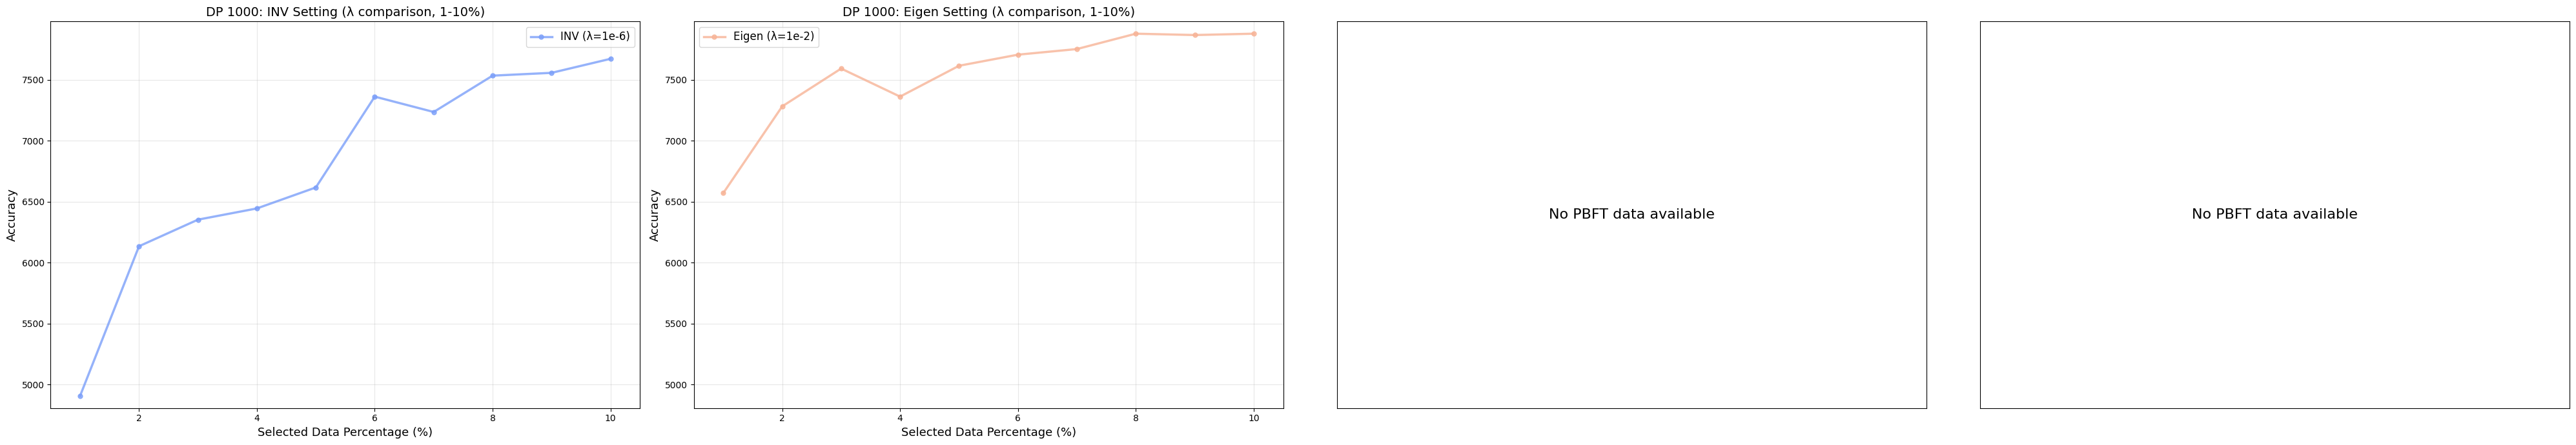

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
rank = 10
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [4908, 6135, 6353, 6445, 6617, 7362, 7236, 7534, 7557, 7672, 7718, 7833, 7867, 7913, 7959, 7924, 7959, 7924, 7970, 8016, 8016, 8016, 7959, 8016, 8050, 8119, 8085, 8165, 8188, 8245, 8245, 8234, 8257, 8280, 8257, 8291, 8314, 8303, 8291, 8326, 8349, 8337, 8326, 8337, 8372, 8406, 8372, 8360, 8394, 8383, 8360, 8268, 8326, 8349, 8337, 8314, 8291, 8257, 8291, 8291, 8314, 8326, 8303, 8349, 8349, 8326, 8314, 8326, 8349, 8314, 8326, 8337, 8360, 8337, 8337, 8326, 8303, 8326, 8326, 8372, 8406, 8383, 8360, 8406, 8383, 8349, 8372, 8372, 8349, 8337, 8394, 8463, 8498, 8498, 8509, 8486, 8509, 8475, 8509, 8417] 
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [6571, 7282, 7592, 7362, 7615, 7706, 7752, 7878, 7867, 7878, 7867, 7913, 7856, 7878, 7913, 7856, 7901, 7936, 8073, 8062, 8096, 8005, 8062, 8062, 8085, 8165, 8188, 8165, 8234, 8234, 8211, 8165, 8234, 8234, 8291, 8245, 8200, 8245, 8165, 8245, 8222, 8211, 8188, 8188, 8200, 8211, 8211, 8211, 8222, 8200, 8211, 8234, 8234, 8177, 8211, 8222, 8222, 8234, 8222, 8245, 8200, 8234, 8234, 8245, 8234, 8245, 8268, 8257, 8234, 8234, 8245, 8245, 8222, 8211, 8268, 8280, 8234, 8234, 8234, 8234, 8257, 8280, 8257, 8222, 8234, 8211, 8200, 8165, 8200, 8245, 8245, 8280, 8245, 8234, 8234, 8245, 8257, 8360, 8337, 8245]      
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6      = [6388, 7030, 6537, 6927, 7213, 7546, 7305, 7661, 7695, 7477, 7603, 7557, 7638, 7672, 7695, 7924, 8016, 8016, 8062, 8016, 8119, 8119, 8119, 8188, 8245, 8222, 8245, 8234, 8200, 8188, 8245, 8222, 8222, 8234, 8280, 8234, 8211, 8177, 8211, 8200, 8257, 8165, 8222, 8211, 8234, 8291, 8257, 8234, 8222, 8303, 8257, 8291, 8234, 8314, 8257, 8211, 8245, 8234, 8222, 8177, 8200, 8222, 8200, 8188, 8280, 8291, 8211, 8245, 8268, 8303, 8303, 8222, 8268, 8234, 8245, 8280, 8303, 8303, 8326, 8360, 8372, 8349, 8383, 8360, 8360, 8303, 8337, 8360, 8360, 8372, 8349, 8349, 8349, 8394, 8383, 8360, 8406, 8406, 8406, 8417]  
r_inv_lam1e_5      = None
r_inv_lam1e_4      = None
r_inv_lam1e_3      = None
r_inv_lam1e_2      = None
r_inv_lam1e_1      = None
r_eigen_lam1e_6    = None
r_eigen_lam1e_5    = None
r_eigen_lam1e_4    = None
r_eigen_lam1e_3    = None
r_eigen_lam1e_2    = [6525, 7179, 6204, 7099, 6640, 6583, 6720, 7248, 7213, 6938, 6525, 6869, 6892, 6869, 7328, 7317, 7764, 7856, 7913, 7924, 7890, 7947, 7833, 7787, 7936, 7833, 7936, 8005, 8005, 8234, 8096, 8062, 8142, 8119, 8200, 8119, 8165, 8177, 8165, 8073, 8188, 8165, 8154, 8108, 8177, 8142, 8188, 8222, 8177, 8188, 8165, 8200, 8142, 8096, 8188, 8165, 8142, 8165, 8200, 8222, 8222, 8245, 8211, 8234, 8200, 8234, 8245, 8257, 8234, 8268, 8268, 8245, 8257, 8268, 8257, 8268, 8280, 8280, 8280, 8326, 8303, 8326, 8337, 8326, 8372, 8303, 8314, 8314, 8291, 8291, 8280, 8291, 8303, 8303, 8326, 8303, 8314, 8314, 8268, 8245]
r_eigen_lam1e_1    = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse colors: high lambda (1e-1) gets red, low lambda (1e-6) gets blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1] if len(colors) > 1 else colors[-1]  # Lambda 1e-2 color (index 1)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom range for subplots (1,1) and (1,2)
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV Setting (λ comparison, 1-10%) =====
ax_left = axes[0]

# INV lambda configs (1e-1 to 1e-6)
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlim(0.5, zoom_percent + 0.5)
ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen Setting (λ comparison, 1-10%) =====
ax_middle = axes[1]

# Eigen lambda configs (1e-1 to 1e-6)
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'Eigen (λ={lam_label})', alpha=0.8)

ax_middle.set_xlim(0.5, zoom_percent + 0.5)
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Synchronize y-axis for (1,1) and (1,2) =====
# Collect all values from both subplots
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

# Set same y-axis limits for both subplots
if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

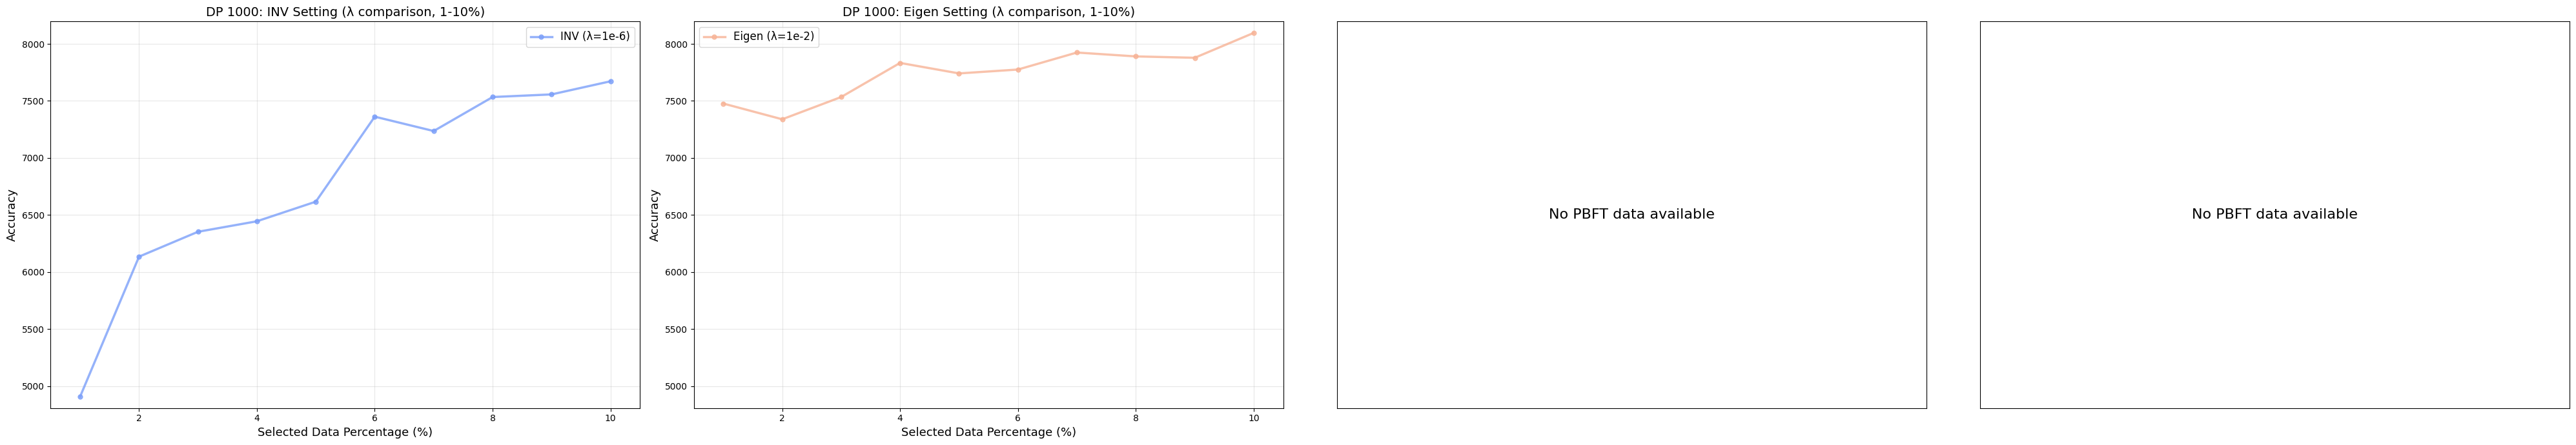

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
rank = 20
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [4908, 6135, 6353, 6445, 6617, 7362, 7236, 7534, 7557, 7672, 7718, 7833, 7867, 7913, 7959, 7924, 7959, 7924, 7970, 8016, 8016, 8016, 7959, 8016, 8050, 8119, 8085, 8165, 8188, 8245, 8245, 8234, 8257, 8280, 8257, 8291, 8314, 8303, 8291, 8326, 8349, 8337, 8326, 8337, 8372, 8406, 8372, 8360, 8394, 8383, 8360, 8268, 8326, 8349, 8337, 8314, 8291, 8257, 8291, 8291, 8314, 8326, 8303, 8349, 8349, 8326, 8314, 8326, 8349, 8314, 8326, 8337, 8360, 8337, 8337, 8326, 8303, 8326, 8326, 8372, 8406, 8383, 8360, 8406, 8383, 8349, 8372, 8372, 8349, 8337, 8394, 8463, 8498, 8498, 8509, 8486, 8509, 8475, 8509, 8417] 
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [7477, 7339, 7534, 7833, 7741, 7775, 7924, 7890, 7878, 8096, 8096, 8177, 8165, 8280, 8188, 8257, 8291, 8280, 8234, 8280, 8245, 8222, 8234, 8268, 8211, 8211, 8383, 8394, 8314, 8360, 8360, 8349, 8314, 8360, 8360, 8326, 8394, 8406, 8452, 8452, 8440, 8463, 8406, 8394, 8452, 8429, 8440, 8440, 8417, 8429, 8463, 8475, 8463, 8463, 8463, 8429, 8463, 8463, 8463, 8440, 8475, 8486, 8486, 8417, 8394, 8429, 8394, 8417, 8394, 8429, 8417, 8372, 8383, 8383, 8326, 8326, 8280, 8268, 8349, 8372, 8372, 8337, 8337, 8349, 8360, 8326, 8303, 8291, 8303, 8303, 8280, 8268, 8291, 8314, 8326, 8303, 8268, 8291, 8303, 8337] 
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6      = [6388, 7030, 6537, 6927, 7213, 7546, 7305, 7661, 7695, 7477, 7603, 7557, 7638, 7672, 7695, 7924, 8016, 8016, 8062, 8016, 8119, 8119, 8119, 8188, 8245, 8222, 8245, 8234, 8200, 8188, 8245, 8222, 8222, 8234, 8280, 8234, 8211, 8177, 8211, 8200, 8257, 8165, 8222, 8211, 8234, 8291, 8257, 8234, 8222, 8303, 8257, 8291, 8234, 8314, 8257, 8211, 8245, 8234, 8222, 8177, 8200, 8222, 8200, 8188, 8280, 8291, 8211, 8245, 8268, 8303, 8303, 8222, 8268, 8234, 8245, 8280, 8303, 8303, 8326, 8360, 8372, 8349, 8383, 8360, 8360, 8303, 8337, 8360, 8360, 8372, 8349, 8349, 8349, 8394, 8383, 8360, 8406, 8406, 8406, 8417]  
r_inv_lam1e_5      = None
r_inv_lam1e_4      = None
r_inv_lam1e_3      = None
r_inv_lam1e_2      = None
r_inv_lam1e_1      = None
r_eigen_lam1e_6    = None
r_eigen_lam1e_5    = None
r_eigen_lam1e_4    = None
r_eigen_lam1e_3    = None
r_eigen_lam1e_2    = [6307, 7122, 6250, 6846, 6812, 6950, 6995, 7626, 7580, 7236, 7225, 7053, 7328, 7259, 7317, 7420, 7317, 7294, 7397, 7317, 7351, 7466, 7385, 7546, 7569, 7477, 7557, 7856, 7752, 7924, 7901, 7936, 7982, 7947, 7947, 7982, 8016, 7936, 7856, 7890, 7810, 7856, 7844, 7867, 7901, 7993, 8016, 8016, 7959, 8131, 8119, 8154, 8154, 8165, 8050, 8154, 8154, 8142, 8188, 8280, 8211, 8234, 8222, 8222, 8257, 8211, 8245, 8211, 8177, 8165, 8211, 8211, 8257, 8257, 8257, 8211, 8188, 8188, 8257, 8280, 8303, 8280, 8291, 8268, 8245, 8268, 8280, 8268, 8268, 8268, 8326, 8303, 8314, 8337, 8406, 8406, 8349, 8303, 8314, 8337]
r_eigen_lam1e_1    = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse colors: high lambda (1e-1) gets red, low lambda (1e-6) gets blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1] if len(colors) > 1 else colors[-1]  # Lambda 1e-2 color (index 1)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom range for subplots (1,1) and (1,2)
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV Setting (λ comparison, 1-10%) =====
ax_left = axes[0]

# INV lambda configs (1e-1 to 1e-6)
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlim(0.5, zoom_percent + 0.5)
ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen Setting (λ comparison, 1-10%) =====
ax_middle = axes[1]

# Eigen lambda configs (1e-1 to 1e-6)
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'Eigen (λ={lam_label})', alpha=0.8)

ax_middle.set_xlim(0.5, zoom_percent + 0.5)
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Synchronize y-axis for (1,1) and (1,2) =====
# Collect all values from both subplots
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

# Set same y-axis limits for both subplots
if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

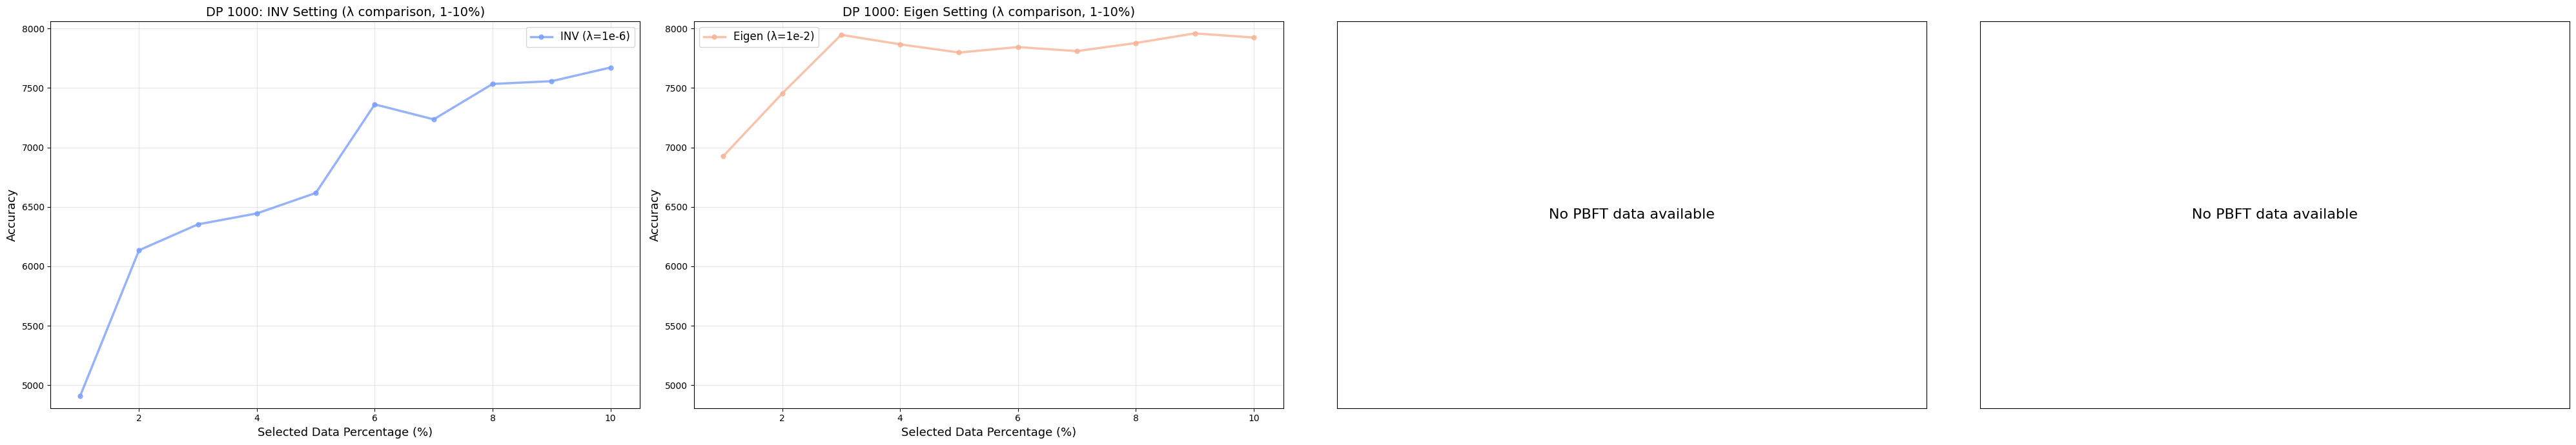

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [4908, 6135, 6353, 6445, 6617, 7362, 7236, 7534, 7557, 7672, 7718, 7833, 7867, 7913, 7959, 7924, 7959, 7924, 7970, 8016, 8016, 8016, 7959, 8016, 8050, 8119, 8085, 8165, 8188, 8245, 8245, 8234, 8257, 8280, 8257, 8291, 8314, 8303, 8291, 8326, 8349, 8337, 8326, 8337, 8372, 8406, 8372, 8360, 8394, 8383, 8360, 8268, 8326, 8349, 8337, 8314, 8291, 8257, 8291, 8291, 8314, 8326, 8303, 8349, 8349, 8326, 8314, 8326, 8349, 8314, 8326, 8337, 8360, 8337, 8337, 8326, 8303, 8326, 8326, 8372, 8406, 8383, 8360, 8406, 8383, 8349, 8372, 8372, 8349, 8337, 8394, 8463, 8498, 8498, 8509, 8486, 8509, 8475, 8509, 8417] 
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [6927, 7454, 7947, 7867, 7798, 7844, 7810, 7878, 7959, 7924, 7947, 8131, 8096, 8200, 8165, 8280, 8360, 8383, 8372, 8417, 8452, 8429, 8429, 8440, 8475, 8475, 8521, 8498, 8498, 8440, 8452, 8486, 8486, 8429, 8452, 8475, 8463, 8463, 8463, 8498, 8475, 8475, 8498, 8509, 8509, 8463, 8440, 8417, 8417, 8383, 8394, 8394, 8383, 8360, 8383, 8452, 8429, 8486, 8486, 8452, 8417, 8429, 8429, 8394, 8326, 8383, 8429, 8429, 8440, 8406, 8394, 8394, 8406, 8406, 8440, 8452, 8440, 8440, 8394, 8417, 8383, 8383, 8394, 8383, 8360, 8337, 8372, 8337, 8337, 8360, 8360, 8303, 8326, 8349, 8406, 8440, 8394, 8372, 8360, 8257]
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6      = [6388, 7030, 6537, 6927, 7213, 7546, 7305, 7661, 7695, 7477, 7603, 7557, 7638, 7672, 7695, 7924, 8016, 8016, 8062, 8016, 8119, 8119, 8119, 8188, 8245, 8222, 8245, 8234, 8200, 8188, 8245, 8222, 8222, 8234, 8280, 8234, 8211, 8177, 8211, 8200, 8257, 8165, 8222, 8211, 8234, 8291, 8257, 8234, 8222, 8303, 8257, 8291, 8234, 8314, 8257, 8211, 8245, 8234, 8222, 8177, 8200, 8222, 8200, 8188, 8280, 8291, 8211, 8245, 8268, 8303, 8303, 8222, 8268, 8234, 8245, 8280, 8303, 8303, 8326, 8360, 8372, 8349, 8383, 8360, 8360, 8303, 8337, 8360, 8360, 8372, 8349, 8349, 8349, 8394, 8383, 8360, 8406, 8406, 8406, 8417]  
r_inv_lam1e_5      = None
r_inv_lam1e_4      = None
r_inv_lam1e_3      = None
r_inv_lam1e_2      = None
r_inv_lam1e_1      = None
r_eigen_lam1e_6    = None
r_eigen_lam1e_5    = None
r_eigen_lam1e_4    = None
r_eigen_lam1e_3    = None
r_eigen_lam1e_2    = [6330, 7041, 6273, 6663, 6709, 6984, 6950, 7546, 7626, 7305, 7236, 7179, 7328, 7362, 7339, 7374, 7454, 7489, 7626, 7603, 7626, 7752, 7695, 7706, 7672, 7454, 7489, 7683, 7649, 7718, 7844, 7557, 7638, 7683, 7489, 7626, 7523, 7511, 7569, 7489, 7638, 7626, 7683, 7580, 7695, 7890, 7821, 7810, 7706, 7741, 7833, 7821, 7752, 7833, 7764, 7878, 7844, 7890, 7936, 7959, 7844, 8005, 7947, 7993, 8039, 8142, 8154, 8131, 8050, 8085, 8108, 8131, 8096, 8108, 8096, 8096, 8085, 8119, 8165, 8245, 8200, 8211, 8268, 8188, 8234, 8234, 8280, 8303, 8280, 8291, 8280, 8291, 8326, 8337, 8349, 8349, 8337, 8326, 8314, 8257]
r_eigen_lam1e_1    = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse colors: high lambda (1e-1) gets red, low lambda (1e-6) gets blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1] if len(colors) > 1 else colors[-1]  # Lambda 1e-2 color (index 1)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom range for subplots (1,1) and (1,2)
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV Setting (λ comparison, 1-10%) =====
ax_left = axes[0]

# INV lambda configs (1e-1 to 1e-6)
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlim(0.5, zoom_percent + 0.5)
ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen Setting (λ comparison, 1-10%) =====
ax_middle = axes[1]

# Eigen lambda configs (1e-1 to 1e-6)
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'Eigen (λ={lam_label})', alpha=0.8)

ax_middle.set_xlim(0.5, zoom_percent + 0.5)
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Synchronize y-axis for (1,1) and (1,2) =====
# Collect all values from both subplots
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

# Set same y-axis limits for both subplots
if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

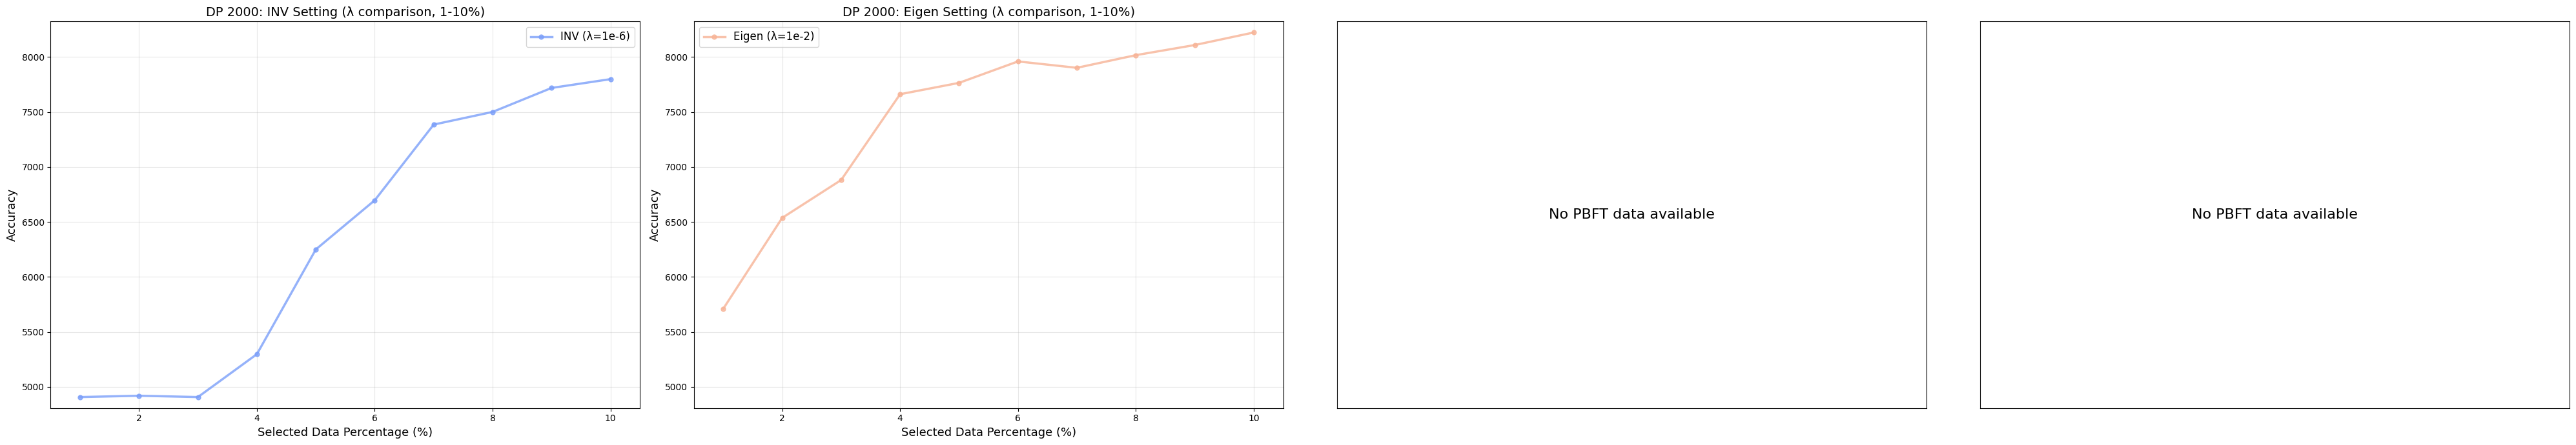

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
rank = 10
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [4908, 4920, 4908, 5298, 6250, 6697, 7385, 7500, 7718, 7798, 7833, 7936, 7959, 8016, 8062, 8016, 7970, 7947, 8028, 8062, 8154, 8131, 8200, 8131, 8177, 8200, 8188, 8177, 8257, 8280, 8268, 8268, 8280, 8257, 8234, 8291, 8257, 8337, 8291, 8326, 8337, 8326, 8326, 8291, 8326, 8326, 8280, 8326, 8372, 8394, 8417, 8406, 8417, 8417, 8417, 8417, 8417, 8463, 8463, 8475, 8429, 8440, 8475, 8475, 8509, 8521, 8521, 8475, 8509, 8498, 8498, 8521, 8521, 8567, 8544, 8544, 8544, 8567, 8589, 8578, 8555, 8555, 8567, 8589, 8578, 8555, 8567, 8578, 8555, 8555, 8555, 8555, 8567, 8544, 8544, 8578, 8521, 8578, 8624, 8486]     
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [5711, 6537, 6881, 7661, 7764, 7959, 7901, 8016, 8108, 8222, 8085, 8073, 8200, 8222, 8291, 8372, 8314, 8360, 8337, 8360, 8406, 8326, 8280, 8349, 8326, 8383, 8394, 8349, 8394, 8429, 8498, 8498, 8463, 8452, 8452, 8417, 8440, 8406, 8417, 8394, 8372, 8486, 8440, 8440, 8463, 8452, 8509, 8509, 8498, 8486, 8463, 8452, 8463, 8475, 8429, 8440, 8417, 8452, 8452, 8406, 8429, 8452, 8406, 8406, 8429, 8417, 8440, 8429, 8417, 8452, 8475, 8498, 8452, 8498, 8452, 8498, 8463, 8452, 8440, 8429, 8417, 8417, 8394, 8406, 8440, 8429, 8429, 8417, 8429, 8394, 8394, 8383, 8349, 8314, 8303, 8291, 8303, 8372, 8349, 8360] 
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6      = [5424, 7271, 7374, 7431, 7385, 7638, 7626, 7787, 8016, 8085, 7959, 7982, 8165, 8085, 7936, 8028, 8096, 8085, 8188, 8211, 8188, 8039, 8096, 8039, 8096, 8073, 8085, 8050, 7993, 8085, 8096, 8119, 8165, 8142, 8200, 8177, 8314, 8211, 8268, 8234, 8234, 8303, 8303, 8245, 8337, 8326, 8360, 8372, 8360, 8326, 8337, 8314, 8280, 8314, 8291, 8268, 8314, 8280, 8280, 8349, 8349, 8337, 8349, 8417, 8440, 8383, 8463, 8429, 8406, 8360, 8394, 8406, 8417, 8383, 8406, 8417, 8429, 8372, 8394, 8406, 8406, 8394, 8406, 8463, 8440, 8440, 8463, 8440, 8440, 8417, 8429, 8440, 8417, 8440, 8463, 8463, 8521, 8498, 8475, 8486]
r_inv_lam1e_5      = None
r_inv_lam1e_4      = None
r_inv_lam1e_3      = None
r_inv_lam1e_2      = None
r_inv_lam1e_1      = None
r_eigen_lam1e_6    = None
r_eigen_lam1e_5    = None
r_eigen_lam1e_4    = None
r_eigen_lam1e_3    = None
r_eigen_lam1e_2    = [5401, 7317, 7305, 6778, 6663, 6812, 6950, 7064, 7030, 6950, 6915, 7041, 7408, 7500, 7557, 7683, 7856, 7729, 7890, 7936, 7890, 7810, 7810, 7810, 7901, 7959, 7856, 8005, 7993, 7959, 7947, 8005, 8005, 8039, 8165, 8234, 8257, 8200, 8188, 8188, 8200, 8211, 8188, 8177, 8268, 8188, 8257, 8222, 8245, 8245, 8268, 8257, 8211, 8257, 8291, 8303, 8326, 8314, 8337, 8268, 8291, 8280, 8337, 8394, 8383, 8394, 8429, 8463, 8440, 8383, 8372, 8406, 8406, 8440, 8429, 8349, 8394, 8349, 8383, 8394, 8394, 8429, 8429, 8417, 8383, 8394, 8394, 8383, 8360, 8326, 8337, 8349, 8360, 8360, 8360, 8360, 8383, 8394, 8372, 8360]  
r_eigen_lam1e_1    = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse colors: high lambda (1e-1) gets red, low lambda (1e-6) gets blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1] if len(colors) > 1 else colors[-1]  # Lambda 1e-2 color (index 1)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom range for subplots (1,1) and (1,2)
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV Setting (λ comparison, 1-10%) =====
ax_left = axes[0]

# INV lambda configs (1e-1 to 1e-6)
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlim(0.5, zoom_percent + 0.5)
ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen Setting (λ comparison, 1-10%) =====
ax_middle = axes[1]

# Eigen lambda configs (1e-1 to 1e-6)
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'Eigen (λ={lam_label})', alpha=0.8)

ax_middle.set_xlim(0.5, zoom_percent + 0.5)
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Synchronize y-axis for (1,1) and (1,2) =====
# Collect all values from both subplots
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

# Set same y-axis limits for both subplots
if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

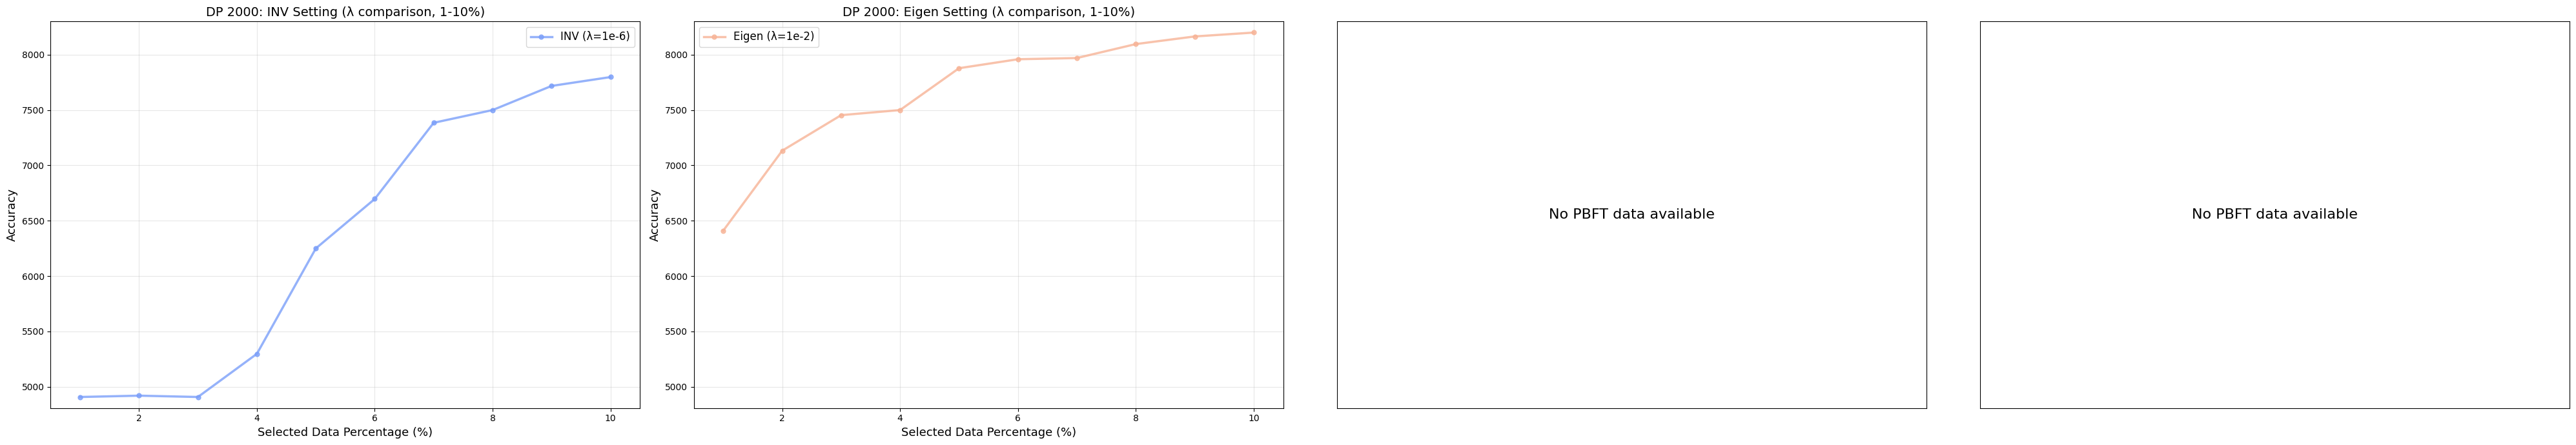

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
rank = 20
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [4908, 4920, 4908, 5298, 6250, 6697, 7385, 7500, 7718, 7798, 7833, 7936, 7959, 8016, 8062, 8016, 7970, 7947, 8028, 8062, 8154, 8131, 8200, 8131, 8177, 8200, 8188, 8177, 8257, 8280, 8268, 8268, 8280, 8257, 8234, 8291, 8257, 8337, 8291, 8326, 8337, 8326, 8326, 8291, 8326, 8326, 8280, 8326, 8372, 8394, 8417, 8406, 8417, 8417, 8417, 8417, 8417, 8463, 8463, 8475, 8429, 8440, 8475, 8475, 8509, 8521, 8521, 8475, 8509, 8498, 8498, 8521, 8521, 8567, 8544, 8544, 8544, 8567, 8589, 8578, 8555, 8555, 8567, 8589, 8578, 8555, 8567, 8578, 8555, 8555, 8555, 8555, 8567, 8544, 8544, 8578, 8521, 8578, 8624, 8486]     
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [6411, 7133, 7454, 7500, 7878, 7959, 7970, 8096, 8165, 8200, 8200, 8268, 8268, 8326, 8291, 8222, 8257, 8222, 8314, 8268, 8337, 8406, 8440, 8452, 8452, 8498, 8440, 8429, 8452, 8417, 8406, 8452, 8417, 8463, 8498, 8429, 8567, 8578, 8521, 8544, 8544, 8555, 8509, 8509, 8521, 8498, 8521, 8498, 8532, 8578, 8555, 8578, 8567, 8578, 8567, 8567, 8567, 8544, 8647, 8601, 8567, 8544, 8555, 8544, 8544, 8555, 8532, 8521, 8498, 8486, 8498, 8486, 8509, 8463, 8486, 8475, 8475, 8498, 8463, 8486, 8486, 8486, 8486, 8475, 8498, 8509, 8486, 8429, 8429, 8463, 8475, 8417, 8440, 8440, 8463, 8452, 8440, 8475, 8486, 8429]  
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6      = [5424, 7271, 7374, 7431, 7385, 7638, 7626, 7787, 8016, 8085, 7959, 7982, 8165, 8085, 7936, 8028, 8096, 8085, 8188, 8211, 8188, 8039, 8096, 8039, 8096, 8073, 8085, 8050, 7993, 8085, 8096, 8119, 8165, 8142, 8200, 8177, 8314, 8211, 8268, 8234, 8234, 8303, 8303, 8245, 8337, 8326, 8360, 8372, 8360, 8326, 8337, 8314, 8280, 8314, 8291, 8268, 8314, 8280, 8280, 8349, 8349, 8337, 8349, 8417, 8440, 8383, 8463, 8429, 8406, 8360, 8394, 8406, 8417, 8383, 8406, 8417, 8429, 8372, 8394, 8406, 8406, 8394, 8406, 8463, 8440, 8440, 8463, 8440, 8440, 8417, 8429, 8440, 8417, 8440, 8463, 8463, 8521, 8498, 8475, 8486]
r_inv_lam1e_5      = None
r_inv_lam1e_4      = None
r_inv_lam1e_3      = None
r_inv_lam1e_2      = None
r_inv_lam1e_1      = None
r_eigen_lam1e_6    = None
r_eigen_lam1e_5    = None
r_eigen_lam1e_4    = None
r_eigen_lam1e_3    = None
r_eigen_lam1e_2    = [5470, 7431, 7592, 6858, 6663, 7018, 6984, 7225, 7603, 7339, 7339, 7592, 7603, 7511, 7649, 7729, 7466, 7179, 7351, 7397, 7603, 7592, 7523, 7500, 7374, 7569, 7592, 7775, 7592, 7592, 7695, 7729, 7752, 7718, 8016, 8016, 8119, 8005, 7878, 8108, 8096, 8085, 8050, 8096, 8108, 8108, 8131, 8108, 8222, 8165, 8234, 8303, 8245, 8314, 8268, 8314, 8326, 8349, 8337, 8360, 8314, 8337, 8303, 8349, 8394, 8337, 8452, 8452, 8475, 8429, 8429, 8440, 8532, 8475, 8498, 8440, 8509, 8498, 8521, 8475, 8509, 8486, 8486, 8486, 8509, 8475, 8452, 8417, 8383, 8394, 8383, 8452, 8429, 8429, 8452, 8452, 8463, 8452, 8452, 8429]
r_eigen_lam1e_1    = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse colors: high lambda (1e-1) gets red, low lambda (1e-6) gets blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1] if len(colors) > 1 else colors[-1]  # Lambda 1e-2 color (index 1)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom range for subplots (1,1) and (1,2)
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV Setting (λ comparison, 1-10%) =====
ax_left = axes[0]

# INV lambda configs (1e-1 to 1e-6)
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlim(0.5, zoom_percent + 0.5)
ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen Setting (λ comparison, 1-10%) =====
ax_middle = axes[1]

# Eigen lambda configs (1e-1 to 1e-6)
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'Eigen (λ={lam_label})', alpha=0.8)

ax_middle.set_xlim(0.5, zoom_percent + 0.5)
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Synchronize y-axis for (1,1) and (1,2) =====
# Collect all values from both subplots
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

# Set same y-axis limits for both subplots
if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

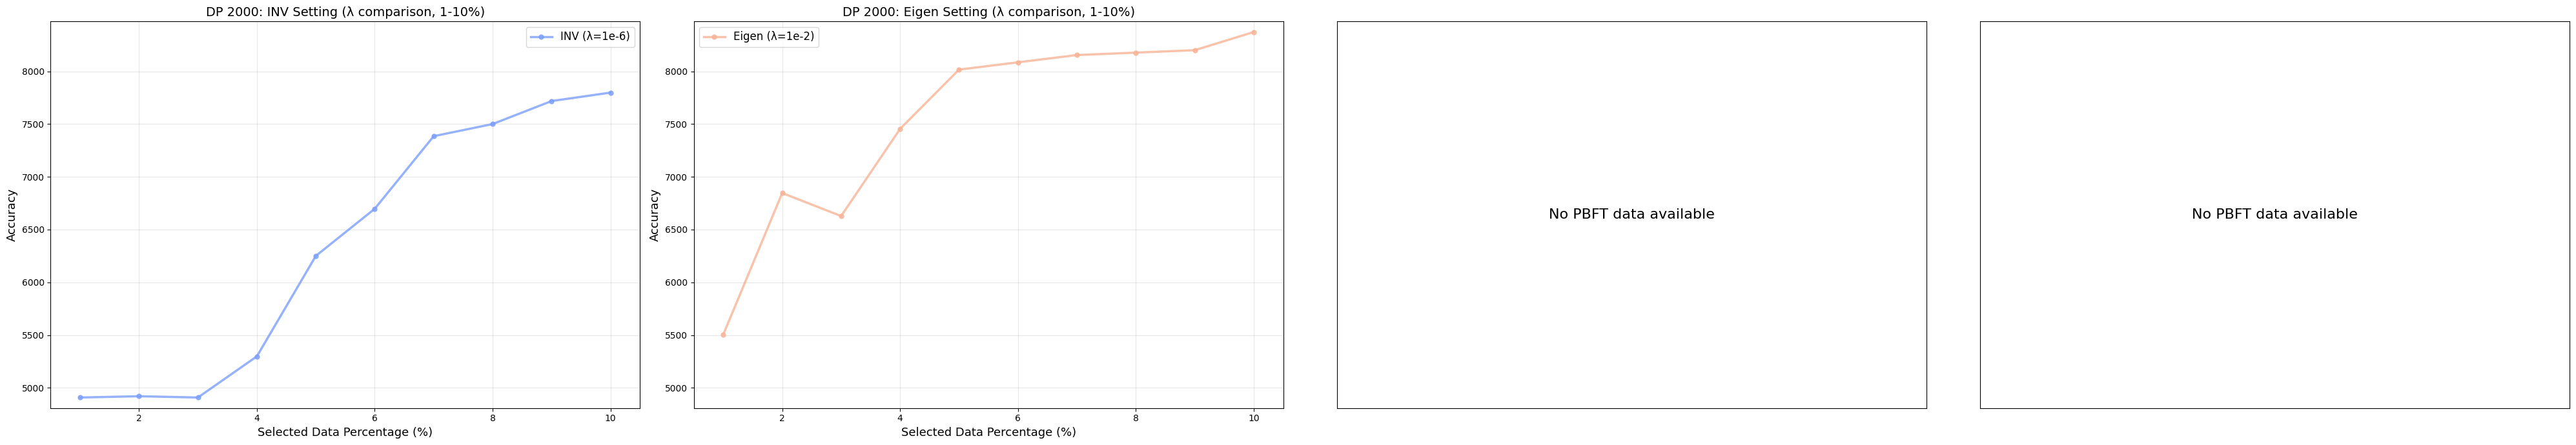

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [4908, 4920, 4908, 5298, 6250, 6697, 7385, 7500, 7718, 7798, 7833, 7936, 7959, 8016, 8062, 8016, 7970, 7947, 8028, 8062, 8154, 8131, 8200, 8131, 8177, 8200, 8188, 8177, 8257, 8280, 8268, 8268, 8280, 8257, 8234, 8291, 8257, 8337, 8291, 8326, 8337, 8326, 8326, 8291, 8326, 8326, 8280, 8326, 8372, 8394, 8417, 8406, 8417, 8417, 8417, 8417, 8417, 8463, 8463, 8475, 8429, 8440, 8475, 8475, 8509, 8521, 8521, 8475, 8509, 8498, 8498, 8521, 8521, 8567, 8544, 8544, 8544, 8567, 8589, 8578, 8555, 8555, 8567, 8589, 8578, 8555, 8567, 8578, 8555, 8555, 8555, 8555, 8567, 8544, 8544, 8578, 8521, 8578, 8624, 8486]     
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [5505, 6846, 6628, 7454, 8016, 8085, 8154, 8177, 8200, 8372, 8303, 8211, 8177, 8142, 8165, 8234, 8303, 8257, 8245, 8268, 8349, 8349, 8417, 8372, 8417, 8532, 8521, 8532, 8567, 8521, 8567, 8567, 8589, 8544, 8521, 8521, 8532, 8509, 8532, 8521, 8521, 8624, 8589, 8601, 8624, 8486, 8452, 8544, 8589, 8521, 8555, 8544, 8578, 8555, 8589, 8601, 8624, 8635, 8647, 8635, 8624, 8624, 8658, 8635, 8658, 8624, 8601, 8589, 8647, 8693, 8601, 8647, 8635, 8578, 8544, 8555, 8567, 8567, 8567, 8532, 8578, 8532, 8544, 8544, 8509, 8498, 8521, 8532, 8532, 8509, 8509, 8498, 8532, 8475, 8440, 8429, 8429, 8452, 8463, 8429]   
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6      = [5424, 7271, 7374, 7431, 7385, 7638, 7626, 7787, 8016, 8085, 7959, 7982, 8165, 8085, 7936, 8028, 8096, 8085, 8188, 8211, 8188, 8039, 8096, 8039, 8096, 8073, 8085, 8050, 7993, 8085, 8096, 8119, 8165, 8142, 8200, 8177, 8314, 8211, 8268, 8234, 8234, 8303, 8303, 8245, 8337, 8326, 8360, 8372, 8360, 8326, 8337, 8314, 8280, 8314, 8291, 8268, 8314, 8280, 8280, 8349, 8349, 8337, 8349, 8417, 8440, 8383, 8463, 8429, 8406, 8360, 8394, 8406, 8417, 8383, 8406, 8417, 8429, 8372, 8394, 8406, 8406, 8394, 8406, 8463, 8440, 8440, 8463, 8440, 8440, 8417, 8429, 8440, 8417, 8440, 8463, 8463, 8521, 8498, 8475, 8486]
r_inv_lam1e_5      = None
r_inv_lam1e_4      = None
r_inv_lam1e_3      = None
r_inv_lam1e_2      = None
r_inv_lam1e_1      = None
r_eigen_lam1e_6    = None
r_eigen_lam1e_5    = None
r_eigen_lam1e_4    = None
r_eigen_lam1e_3    = None
r_eigen_lam1e_2    = [5470, 7534, 7718, 7053, 6881, 7248, 7133, 7385, 7718, 7477, 7225, 7546, 7523, 7523, 7557, 7557, 7362, 7385, 7420, 7557, 7661, 7661, 7638, 7638, 7638, 7936, 7810, 7844, 7764, 7798, 7752, 7741, 7695, 7752, 7810, 7810, 7856, 7856, 7901, 7878, 7890, 7936, 7901, 8096, 8028, 7970, 8119, 8131, 8108, 8165, 8177, 8188, 8188, 8108, 8165, 8200, 8131, 8096, 8028, 8108, 8073, 8280, 8268, 8337, 8326, 8303, 8360, 8360, 8337, 8326, 8337, 8360, 8383, 8406, 8349, 8417, 8429, 8417, 8440, 8417, 8440, 8452, 8440, 8452, 8417, 8440, 8429, 8394, 8394, 8406, 8406, 8417, 8406, 8394, 8440, 8486, 8486, 8498, 8463, 8429]
r_eigen_lam1e_1    = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse colors: high lambda (1e-1) gets red, low lambda (1e-6) gets blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1] if len(colors) > 1 else colors[-1]  # Lambda 1e-2 color (index 1)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom range for subplots (1,1) and (1,2)
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV Setting (λ comparison, 1-10%) =====
ax_left = axes[0]

# INV lambda configs (1e-1 to 1e-6)
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlim(0.5, zoom_percent + 0.5)
ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen Setting (λ comparison, 1-10%) =====
ax_middle = axes[1]

# Eigen lambda configs (1e-1 to 1e-6)
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'Eigen (λ={lam_label})', alpha=0.8)

ax_middle.set_xlim(0.5, zoom_percent + 0.5)
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Synchronize y-axis for (1,1) and (1,2) =====
# Collect all values from both subplots
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

# Set same y-axis limits for both subplots
if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

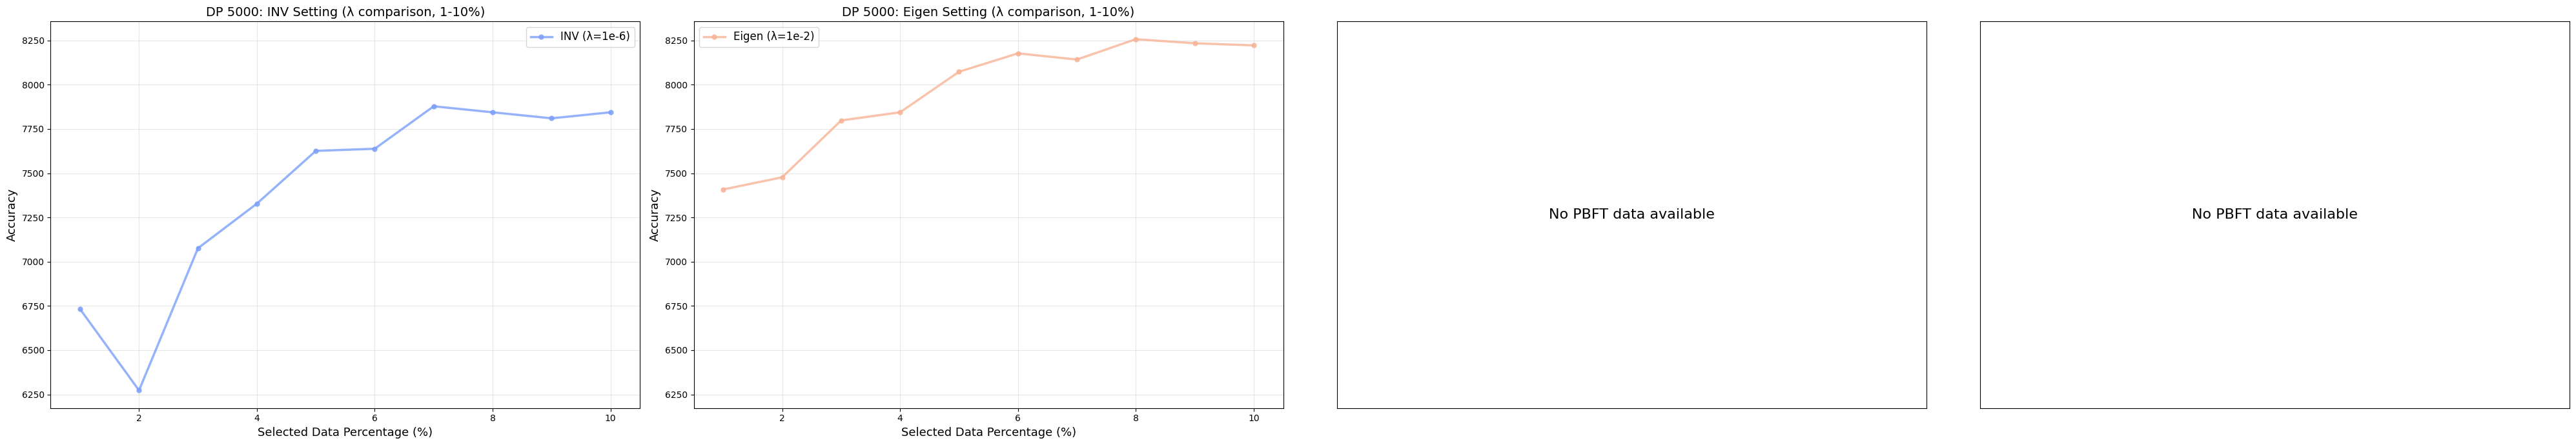

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
rank = 10
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [6732, 6273, 7076, 7328, 7626, 7638, 7878, 7844, 7810, 7844, 7890, 8039, 8096, 8131, 8131, 8222, 8245, 8234, 8211, 8303, 8268, 8314, 8314, 8337, 8383, 8463, 8429, 8509, 8521, 8475, 8509, 8509, 8532, 8544, 8589, 8612, 8589, 8567, 8555, 8589, 8589, 8589, 8578, 8578, 8589, 8578, 8555, 8555, 8601, 8612, 8635, 8647, 8635, 8658, 8670, 8693, 8647, 8647, 8635, 8635, 8670, 8612, 8635, 8635, 8635, 8647, 8647, 8658, 8647, 8635, 8693, 8716, 8681, 8670, 8704, 8693, 8693, 8681, 8716, 8704, 8716, 8693, 8658, 8635, 8681, 8670, 8601, 8635, 8624, 8693, 8681, 8716, 8681, 8693, 8704, 8658, 8635, 8624, 8647, 8429]
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [7408, 7477, 7798, 7844, 8073, 8177, 8142, 8257, 8234, 8222, 8200, 8257, 8372, 8291, 8406, 8417, 8440, 8406, 8463, 8475, 8521, 8601, 8635, 8601, 8658, 8567, 8601, 8578, 8647, 8647, 8647, 8704, 8647, 8670, 8693, 8773, 8716, 8716, 8750, 8739, 8761, 8727, 8750, 8761, 8773, 8761, 8739, 8761, 8727, 8761, 8739, 8750, 8773, 8750, 8761, 8750, 8761, 8739, 8761, 8761, 8750, 8773, 8773, 8761, 8750, 8704, 8739, 8750, 8727, 8693, 8727, 8727, 8727, 8727, 8750, 8704, 8716, 8750, 8727, 8761, 8739, 8739, 8739, 8716, 8716, 8727, 8716, 8727, 8693, 8727, 8704, 8681, 8704, 8670, 8635, 8601, 8624, 8601, 8601, 8578]  
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6      = [6479, 7443, 7890, 8016, 8085, 8108, 8085, 8050, 8028, 7936, 8005, 7890, 7867, 7901, 8050, 7913, 7821, 7833, 8016, 8016, 8188, 8177, 8211, 8291, 8406, 8406, 8429, 8452, 8417, 8349, 8417, 8394, 8406, 8429, 8406, 8406, 8360, 8417, 8394, 8394, 8509, 8452, 8406, 8521, 8555, 8567, 8521, 8544, 8532, 8544, 8521, 8509, 8532, 8589, 8612, 8589, 8532, 8567, 8555, 8578, 8578, 8486, 8486, 8475, 8486, 8521, 8555, 8463, 8521, 8567, 8544, 8578, 8567, 8658, 8589, 8567, 8532, 8555, 8555, 8567, 8578, 8567, 8532, 8544, 8544, 8521, 8532, 8475, 8498, 8509, 8486, 8463, 8475, 8486, 8452, 8452, 8429, 8463, 8452, 8429] 
r_inv_lam1e_5      = None
r_inv_lam1e_4      = None
r_inv_lam1e_3      = None
r_inv_lam1e_2      = None
r_inv_lam1e_1      = None
r_eigen_lam1e_6    = None
r_eigen_lam1e_5    = None
r_eigen_lam1e_4    = None
r_eigen_lam1e_3    = None
r_eigen_lam1e_2    = [7018, 7580, 7695, 7706, 7878, 7729, 7500, 7454, 7511, 7385, 7580, 7466, 7385, 7557, 7752, 7649, 7615, 7557, 7729, 7833, 7947, 7993, 7901, 7936, 8085, 8119, 8119, 8200, 8222, 8200, 8314, 8234, 8349, 8291, 8280, 8314, 8314, 8280, 8326, 8291, 8257, 8291, 8337, 8394, 8337, 8394, 8406, 8417, 8417, 8440, 8452, 8509, 8463, 8452, 8475, 8475, 8452, 8463, 8440, 8486, 8463, 8498, 8555, 8532, 8578, 8532, 8521, 8555, 8555, 8544, 8555, 8555, 8578, 8544, 8532, 8486, 8486, 8521, 8486, 8486, 8486, 8486, 8509, 8509, 8544, 8521, 8567, 8567, 8532, 8509, 8521, 8509, 8532, 8532, 8532, 8498, 8509, 8544, 8555, 8578]  
r_eigen_lam1e_1    = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse colors: high lambda (1e-1) gets red, low lambda (1e-6) gets blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1] if len(colors) > 1 else colors[-1]  # Lambda 1e-2 color (index 1)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom range for subplots (1,1) and (1,2)
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV Setting (λ comparison, 1-10%) =====
ax_left = axes[0]

# INV lambda configs (1e-1 to 1e-6)
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlim(0.5, zoom_percent + 0.5)
ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen Setting (λ comparison, 1-10%) =====
ax_middle = axes[1]

# Eigen lambda configs (1e-1 to 1e-6)
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'Eigen (λ={lam_label})', alpha=0.8)

ax_middle.set_xlim(0.5, zoom_percent + 0.5)
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Synchronize y-axis for (1,1) and (1,2) =====
# Collect all values from both subplots
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

# Set same y-axis limits for both subplots
if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

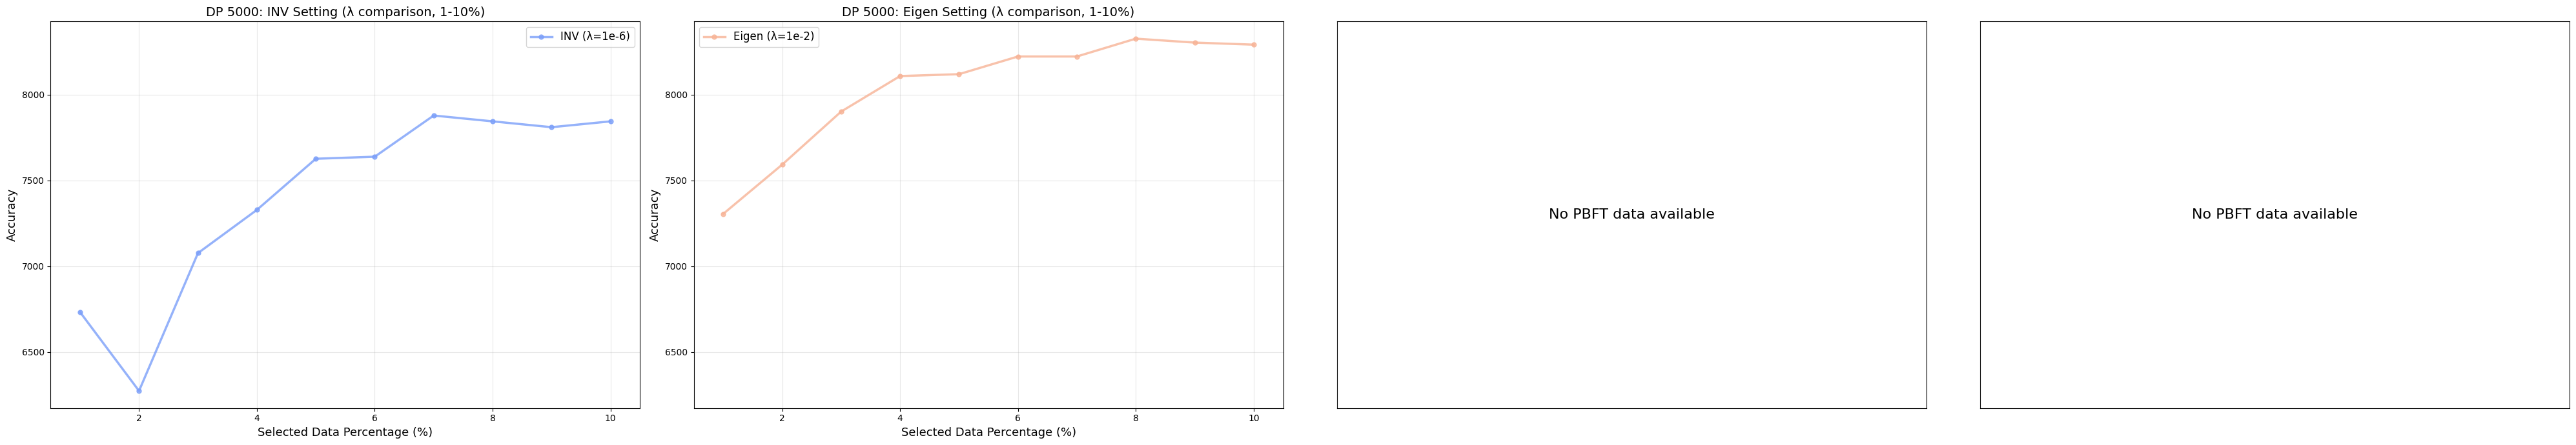

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
rank = 20
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [6732, 6273, 7076, 7328, 7626, 7638, 7878, 7844, 7810, 7844, 7890, 8039, 8096, 8131, 8131, 8222, 8245, 8234, 8211, 8303, 8268, 8314, 8314, 8337, 8383, 8463, 8429, 8509, 8521, 8475, 8509, 8509, 8532, 8544, 8589, 8612, 8589, 8567, 8555, 8589, 8589, 8589, 8578, 8578, 8589, 8578, 8555, 8555, 8601, 8612, 8635, 8647, 8635, 8658, 8670, 8693, 8647, 8647, 8635, 8635, 8670, 8612, 8635, 8635, 8635, 8647, 8647, 8658, 8647, 8635, 8693, 8716, 8681, 8670, 8704, 8693, 8693, 8681, 8716, 8704, 8716, 8693, 8658, 8635, 8681, 8670, 8601, 8635, 8624, 8693, 8681, 8716, 8681, 8693, 8704, 8658, 8635, 8624, 8647, 8429]
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [7305, 7592, 7901, 8108, 8119, 8222, 8222, 8326, 8303, 8291, 8268, 8372, 8440, 8521, 8440, 8452, 8452, 8498, 8475, 8589, 8601, 8555, 8578, 8567, 8544, 8578, 8578, 8601, 8647, 8716, 8681, 8670, 8704, 8658, 8647, 8635, 8670, 8647, 8658, 8693, 8704, 8739, 8727, 8761, 8773, 8807, 8830, 8830, 8830, 8830, 8727, 8773, 8750, 8773, 8750, 8750, 8750, 8761, 8773, 8773, 8727, 8716, 8727, 8761, 8807, 8830, 8761, 8807, 8784, 8796, 8773, 8807, 8773, 8784, 8761, 8750, 8739, 8750, 8716, 8704, 8716, 8658, 8670, 8681, 8704, 8716, 8693, 8670, 8693, 8693, 8739, 8704, 8681, 8658, 8693, 8693, 8635, 8658, 8647, 8567]
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6      = [6479, 7443, 7890, 8016, 8085, 8108, 8085, 8050, 8028, 7936, 8005, 7890, 7867, 7901, 8050, 7913, 7821, 7833, 8016, 8016, 8188, 8177, 8211, 8291, 8406, 8406, 8429, 8452, 8417, 8349, 8417, 8394, 8406, 8429, 8406, 8406, 8360, 8417, 8394, 8394, 8509, 8452, 8406, 8521, 8555, 8567, 8521, 8544, 8532, 8544, 8521, 8509, 8532, 8589, 8612, 8589, 8532, 8567, 8555, 8578, 8578, 8486, 8486, 8475, 8486, 8521, 8555, 8463, 8521, 8567, 8544, 8578, 8567, 8658, 8589, 8567, 8532, 8555, 8555, 8567, 8578, 8567, 8532, 8544, 8544, 8521, 8532, 8475, 8498, 8509, 8486, 8463, 8475, 8486, 8452, 8452, 8429, 8463, 8452, 8429] 
r_inv_lam1e_5      = None
r_inv_lam1e_4      = None
r_inv_lam1e_3      = None
r_inv_lam1e_2      = None
r_inv_lam1e_1      = None
r_eigen_lam1e_6    = None
r_eigen_lam1e_5    = None
r_eigen_lam1e_4    = None
r_eigen_lam1e_3    = None
r_eigen_lam1e_2    = [6881, 7580, 7787, 7947, 8085, 7913, 7833, 7626, 7615, 7546, 7706, 7603, 7706, 7787, 7833, 7752, 7557, 7752, 7764, 7764, 7890, 7993, 7890, 7982, 8108, 8108, 8050, 8154, 8142, 8188, 8234, 8188, 8154, 8222, 8326, 8280, 8280, 8326, 8314, 8245, 8383, 8268, 8394, 8383, 8452, 8360, 8406, 8452, 8452, 8429, 8417, 8417, 8440, 8417, 8475, 8475, 8475, 8532, 8544, 8532, 8532, 8521, 8532, 8486, 8509, 8440, 8463, 8463, 8475, 8509, 8555, 8532, 8578, 8544, 8544, 8532, 8544, 8532, 8555, 8521, 8544, 8532, 8532, 8532, 8555, 8521, 8567, 8601, 8578, 8578, 8567, 8578, 8555, 8578, 8532, 8532, 8567, 8544, 8544, 8567]  
r_eigen_lam1e_1    = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse colors: high lambda (1e-1) gets red, low lambda (1e-6) gets blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1] if len(colors) > 1 else colors[-1]  # Lambda 1e-2 color (index 1)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom range for subplots (1,1) and (1,2)
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV Setting (λ comparison, 1-10%) =====
ax_left = axes[0]

# INV lambda configs (1e-1 to 1e-6)
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlim(0.5, zoom_percent + 0.5)
ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen Setting (λ comparison, 1-10%) =====
ax_middle = axes[1]

# Eigen lambda configs (1e-1 to 1e-6)
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'Eigen (λ={lam_label})', alpha=0.8)

ax_middle.set_xlim(0.5, zoom_percent + 0.5)
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Synchronize y-axis for (1,1) and (1,2) =====
# Collect all values from both subplots
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

# Set same y-axis limits for both subplots
if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

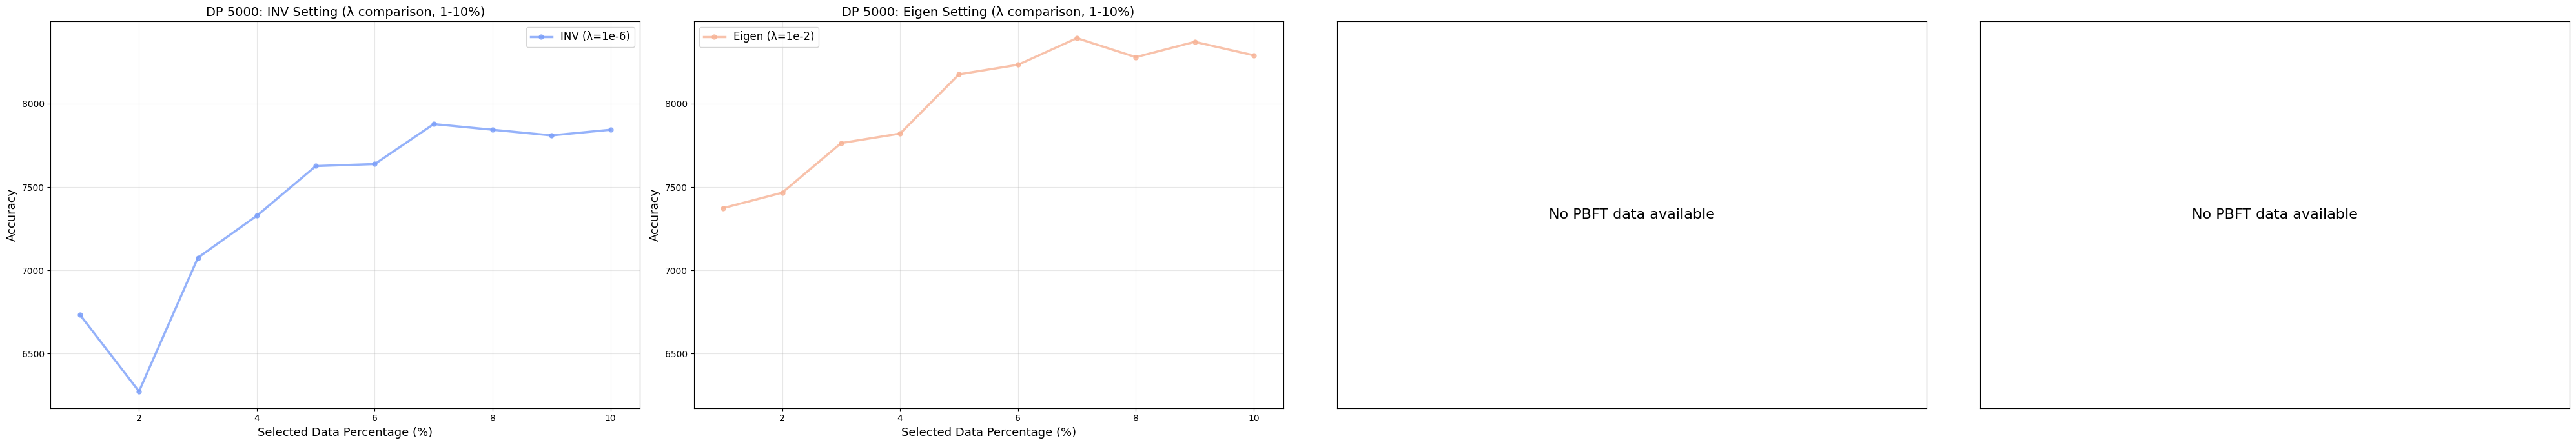

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [6732, 6273, 7076, 7328, 7626, 7638, 7878, 7844, 7810, 7844, 7890, 8039, 8096, 8131, 8131, 8222, 8245, 8234, 8211, 8303, 8268, 8314, 8314, 8337, 8383, 8463, 8429, 8509, 8521, 8475, 8509, 8509, 8532, 8544, 8589, 8612, 8589, 8567, 8555, 8589, 8589, 8589, 8578, 8578, 8589, 8578, 8555, 8555, 8601, 8612, 8635, 8647, 8635, 8658, 8670, 8693, 8647, 8647, 8635, 8635, 8670, 8612, 8635, 8635, 8635, 8647, 8647, 8658, 8647, 8635, 8693, 8716, 8681, 8670, 8704, 8693, 8693, 8681, 8716, 8704, 8716, 8693, 8658, 8635, 8681, 8670, 8601, 8635, 8624, 8693, 8681, 8716, 8681, 8693, 8704, 8658, 8635, 8624, 8647, 8429]
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [7374, 7466, 7764, 7821, 8177, 8234, 8394, 8280, 8372, 8291, 8360, 8452, 8406, 8429, 8372, 8498, 8463, 8463, 8452, 8429, 8498, 8509, 8521, 8532, 8578, 8555, 8578, 8635, 8624, 8647, 8670, 8704, 8750, 8716, 8681, 8739, 8761, 8750, 8739, 8739, 8773, 8819, 8784, 8784, 8784, 8784, 8773, 8796, 8773, 8716, 8761, 8739, 8784, 8761, 8796, 8819, 8807, 8842, 8819, 8830, 8819, 8830, 8830, 8842, 8819, 8853, 8853, 8842, 8807, 8807, 8773, 8796, 8784, 8773, 8830, 8796, 8807, 8784, 8830, 8784, 8796, 8773, 8807, 8796, 8784, 8784, 8819, 8807, 8807, 8773, 8727, 8739, 8739, 8761, 8761, 8727, 8670, 8658, 8578, 8567]
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6      = [6479, 7443, 7890, 8016, 8085, 8108, 8085, 8050, 8028, 7936, 8005, 7890, 7867, 7901, 8050, 7913, 7821, 7833, 8016, 8016, 8188, 8177, 8211, 8291, 8406, 8406, 8429, 8452, 8417, 8349, 8417, 8394, 8406, 8429, 8406, 8406, 8360, 8417, 8394, 8394, 8509, 8452, 8406, 8521, 8555, 8567, 8521, 8544, 8532, 8544, 8521, 8509, 8532, 8589, 8612, 8589, 8532, 8567, 8555, 8578, 8578, 8486, 8486, 8475, 8486, 8521, 8555, 8463, 8521, 8567, 8544, 8578, 8567, 8658, 8589, 8567, 8532, 8555, 8555, 8567, 8578, 8567, 8532, 8544, 8544, 8521, 8532, 8475, 8498, 8509, 8486, 8463, 8475, 8486, 8452, 8452, 8429, 8463, 8452, 8429] 
r_inv_lam1e_5      = None
r_inv_lam1e_4      = None
r_inv_lam1e_3      = None
r_inv_lam1e_2      = None
r_inv_lam1e_1      = None
r_eigen_lam1e_6    = None
r_eigen_lam1e_5    = None
r_eigen_lam1e_4    = None
r_eigen_lam1e_3    = None
r_eigen_lam1e_2    = [6778, 7569, 7821, 7959, 8108, 8085, 7970, 7810, 7844, 7752, 7764, 7718, 7775, 7890, 7913, 7856, 7890, 7901, 7878, 7764, 7833, 7821, 7833, 7890, 7982, 8039, 8062, 8062, 8028, 8073, 8085, 8039, 8154, 8096, 8142, 8154, 8234, 8142, 8142, 8096, 8177, 8200, 8188, 8165, 8222, 8188, 8280, 8337, 8268, 8245, 8360, 8349, 8372, 8394, 8349, 8498, 8486, 8532, 8486, 8578, 8567, 8486, 8486, 8521, 8498, 8463, 8498, 8509, 8498, 8509, 8521, 8544, 8555, 8567, 8532, 8498, 8521, 8509, 8555, 8509, 8486, 8475, 8475, 8383, 8452, 8475, 8475, 8498, 8532, 8544, 8567, 8567, 8555, 8567, 8544, 8544, 8578, 8555, 8578, 8567] 
r_eigen_lam1e_1    = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse colors: high lambda (1e-1) gets red, low lambda (1e-6) gets blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1] if len(colors) > 1 else colors[-1]  # Lambda 1e-2 color (index 1)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom range for subplots (1,1) and (1,2)
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV Setting (λ comparison, 1-10%) =====
ax_left = axes[0]

# INV lambda configs (1e-1 to 1e-6)
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlim(0.5, zoom_percent + 0.5)
ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen Setting (λ comparison, 1-10%) =====
ax_middle = axes[1]

# Eigen lambda configs (1e-1 to 1e-6)
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'Eigen (λ={lam_label})', alpha=0.8)

ax_middle.set_xlim(0.5, zoom_percent + 0.5)
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Synchronize y-axis for (1,1) and (1,2) =====
# Collect all values from both subplots
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

# Set same y-axis limits for both subplots
if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

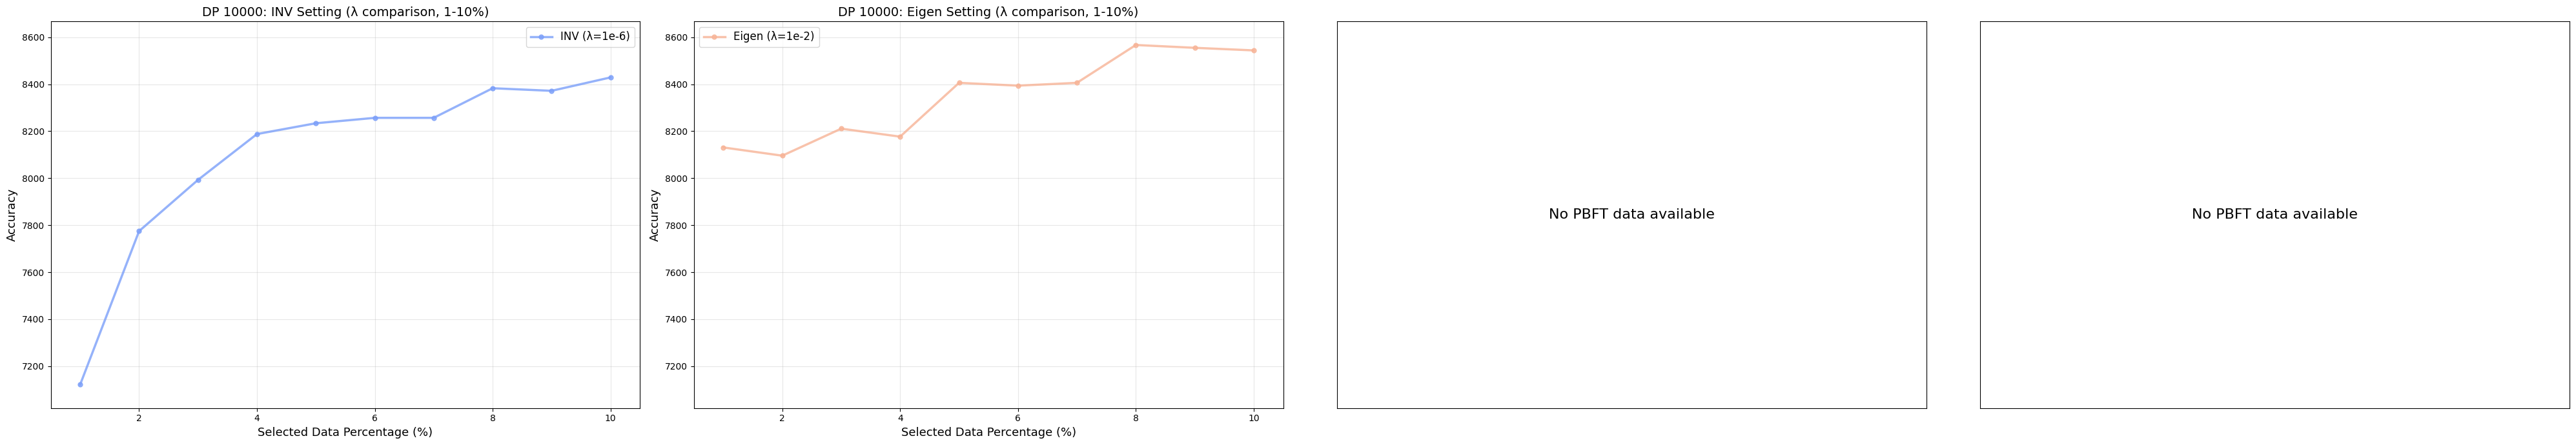

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 10000
rank = 10
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [7122, 7775, 7993, 8188, 8234, 8257, 8257, 8383, 8372, 8429, 8440, 8544, 8658, 8658, 8635, 8704, 8612, 8647, 8647, 8727, 8716, 8739, 8773, 8830, 8842, 8865, 8853, 8876, 8842, 8842, 8830, 8853, 8853, 8842, 8911, 8853, 8842, 8888, 8933, 8888, 8922, 8876, 8911, 8876, 8876, 8876, 8865, 8899, 8865, 8865, 8876, 8842, 8842, 8830, 8865, 8853, 8876, 8876, 8842, 8876, 8853, 8888, 8911, 8922, 8933, 8911, 8911, 8888, 8899, 8888, 8888, 8911, 8911, 8922, 8933, 8899, 8945, 8956, 8899, 8922, 8888, 8911, 8911, 8911, 8945, 8945, 8933, 8922, 8933, 8888, 8876, 8876, 8888, 8876, 8807, 8830, 8693, 8761, 8716, 8589]  
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [8131, 8096, 8211, 8177, 8406, 8394, 8406, 8567, 8555, 8544, 8601, 8601, 8727, 8739, 8739, 8773, 8739, 8750, 8704, 8830, 8830, 8853, 8830, 8842, 8876, 8853, 8853, 8945, 8922, 8911, 8911, 8945, 8945, 8956, 8911, 8888, 8876, 8888, 8911, 8888, 8876, 8899, 8888, 8876, 8899, 8876, 8853, 8853, 8876, 8865, 8830, 8842, 8807, 8807, 8773, 8796, 8807, 8796, 8784, 8807, 8796, 8807, 8807, 8842, 8807, 8807, 8784, 8807, 8784, 8761, 8773, 8773, 8716, 8739, 8704, 8739, 8750, 8716, 8750, 8727, 8704, 8727, 8750, 8704, 8727, 8761, 8761, 8761, 8716, 8716, 8704, 8704, 8693, 8670, 8601, 8578, 8544, 8578, 8589, 8532]  
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6      = [6972, 7867, 8062, 8131, 8096, 8142, 8234, 8177, 8245, 8200, 8383, 8383, 8452, 8498, 8486, 8406, 8360, 8509, 8486, 8509, 8417, 8532, 8452, 8417, 8498, 8452, 8463, 8486, 8486, 8417, 8372, 8372, 8509, 8440, 8486, 8509, 8498, 8463, 8486, 8486, 8578, 8532, 8532, 8498, 8486, 8555, 8567, 8498, 8532, 8486, 8544, 8486, 8521, 8532, 8521, 8486, 8555, 8509, 8544, 8555, 8498, 8544, 8544, 8532, 8475, 8498, 8509, 8486, 8498, 8567, 8532, 8555, 8567, 8555, 8532, 8567, 8589, 8578, 8532, 8532, 8567, 8589, 8578, 8567, 8544, 8567, 8589, 8624, 8601, 8612, 8612, 8578, 8658, 8589, 8578, 8601, 8612, 8589, 8601, 8589]
r_inv_lam1e_5      = None
r_inv_lam1e_4      = None
r_inv_lam1e_3      = None
r_inv_lam1e_2      = None
r_inv_lam1e_1      = None
r_eigen_lam1e_6    = None
r_eigen_lam1e_5    = None
r_eigen_lam1e_4    = None
r_eigen_lam1e_3    = None
r_eigen_lam1e_2    = [6766, 7718, 7798, 7546, 7752, 7787, 7787, 7661, 7741, 7764, 7913, 7890, 7890, 7936, 8039, 8050, 8016, 8119, 8177, 8280, 8188, 8303, 8291, 8349, 8337, 8360, 8372, 8314, 8326, 8314, 8372, 8429, 8475, 8406, 8429, 8360, 8372, 8349, 8372, 8314, 8337, 8291, 8360, 8372, 8349, 8360, 8280, 8349, 8291, 8326, 8360, 8394, 8349, 8360, 8360, 8383, 8383, 8417, 8383, 8440, 8452, 8463, 8463, 8406, 8463, 8406, 8417, 8440, 8417, 8463, 8429, 8463, 8463, 8486, 8463, 8555, 8521, 8532, 8509, 8486, 8509, 8498, 8486, 8498, 8498, 8463, 8498, 8486, 8498, 8521, 8521, 8532, 8509, 8463, 8521, 8532, 8498, 8521, 8532, 8532]
r_eigen_lam1e_1    = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse colors: high lambda (1e-1) gets red, low lambda (1e-6) gets blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1] if len(colors) > 1 else colors[-1]  # Lambda 1e-2 color (index 1)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom range for subplots (1,1) and (1,2)
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV Setting (λ comparison, 1-10%) =====
ax_left = axes[0]

# INV lambda configs (1e-1 to 1e-6)
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlim(0.5, zoom_percent + 0.5)
ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen Setting (λ comparison, 1-10%) =====
ax_middle = axes[1]

# Eigen lambda configs (1e-1 to 1e-6)
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'Eigen (λ={lam_label})', alpha=0.8)

ax_middle.set_xlim(0.5, zoom_percent + 0.5)
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Synchronize y-axis for (1,1) and (1,2) =====
# Collect all values from both subplots
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

# Set same y-axis limits for both subplots
if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

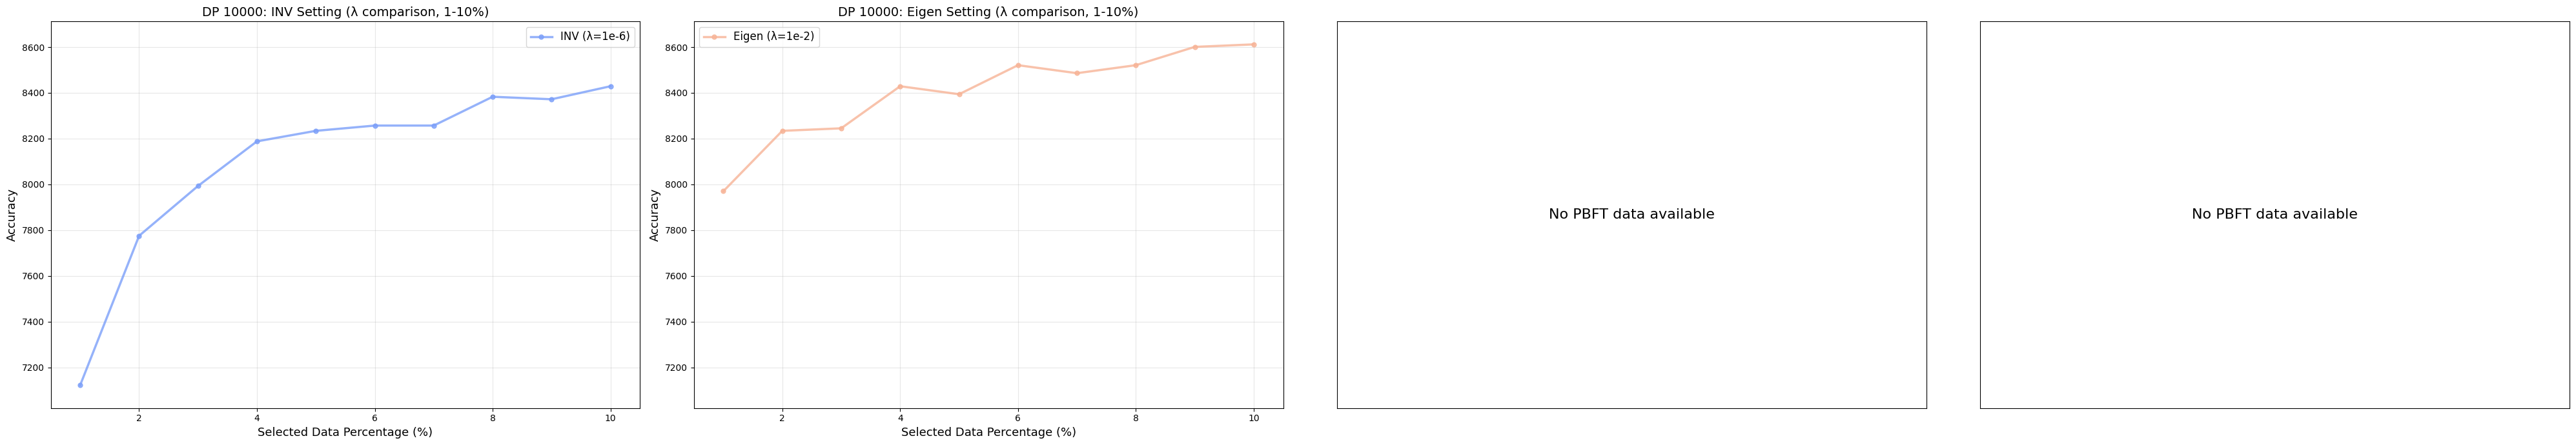

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 10000
rank = 20
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [7122, 7775, 7993, 8188, 8234, 8257, 8257, 8383, 8372, 8429, 8440, 8544, 8658, 8658, 8635, 8704, 8612, 8647, 8647, 8727, 8716, 8739, 8773, 8830, 8842, 8865, 8853, 8876, 8842, 8842, 8830, 8853, 8853, 8842, 8911, 8853, 8842, 8888, 8933, 8888, 8922, 8876, 8911, 8876, 8876, 8876, 8865, 8899, 8865, 8865, 8876, 8842, 8842, 8830, 8865, 8853, 8876, 8876, 8842, 8876, 8853, 8888, 8911, 8922, 8933, 8911, 8911, 8888, 8899, 8888, 8888, 8911, 8911, 8922, 8933, 8899, 8945, 8956, 8899, 8922, 8888, 8911, 8911, 8911, 8945, 8945, 8933, 8922, 8933, 8888, 8876, 8876, 8888, 8876, 8807, 8830, 8693, 8761, 8716, 8589]  
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [7970, 8234, 8245, 8429, 8394, 8521, 8486, 8521, 8601, 8612, 8624, 8716, 8624, 8624, 8624, 8750, 8761, 8819, 8853, 8853, 8922, 8922, 8956, 8945, 8945, 8933, 8933, 8899, 8956, 8911, 8922, 8991, 9025, 9002, 9002, 8968, 9002, 9002, 8968, 8968, 8991, 9037, 8933, 8979, 8968, 8968, 8991, 8991, 8945, 9002, 9025, 8991, 8945, 9002, 8979, 9014, 9014, 9025, 9002, 9025, 8991, 9025, 9014, 9037, 9002, 9025, 9048, 9025, 9048, 9025, 9037, 9002, 9002, 8991, 8991, 8991, 8991, 9002, 8945, 8968, 8956, 8979, 8922, 8865, 8876, 8842, 8807, 8796, 8807, 8784, 8773, 8750, 8704, 8670, 8658, 8601, 8647, 8658, 8589, 8498] 
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6      = [6972, 7867, 8062, 8131, 8096, 8142, 8234, 8177, 8245, 8200, 8383, 8383, 8452, 8498, 8486, 8406, 8360, 8509, 8486, 8509, 8417, 8532, 8452, 8417, 8498, 8452, 8463, 8486, 8486, 8417, 8372, 8372, 8509, 8440, 8486, 8509, 8498, 8463, 8486, 8486, 8578, 8532, 8532, 8498, 8486, 8555, 8567, 8498, 8532, 8486, 8544, 8486, 8521, 8532, 8521, 8486, 8555, 8509, 8544, 8555, 8498, 8544, 8544, 8532, 8475, 8498, 8509, 8486, 8498, 8567, 8532, 8555, 8567, 8555, 8532, 8567, 8589, 8578, 8532, 8532, 8567, 8589, 8578, 8567, 8544, 8567, 8589, 8624, 8601, 8612, 8612, 8578, 8658, 8589, 8578, 8601, 8612, 8589, 8601, 8589]
r_inv_lam1e_5      = None
r_inv_lam1e_4      = None
r_inv_lam1e_3      = None
r_inv_lam1e_2      = None
r_inv_lam1e_1      = None
r_eigen_lam1e_6    = None
r_eigen_lam1e_5    = None
r_eigen_lam1e_4    = None
r_eigen_lam1e_3    = None
r_eigen_lam1e_2    = [6766, 7706, 7890, 7787, 7821, 7867, 8028, 7913, 7947, 8062, 8131, 8142, 8039, 8005, 8005, 8016, 7947, 8119, 8142, 8222, 8257, 8257, 8245, 8280, 8291, 8257, 8245, 8188, 8257, 8188, 8188, 8154, 8245, 8211, 8245, 8291, 8257, 8188, 8245, 8268, 8326, 8360, 8406, 8383, 8360, 8360, 8360, 8349, 8314, 8314, 8314, 8383, 8429, 8463, 8452, 8429, 8429, 8406, 8429, 8498, 8509, 8509, 8463, 8417, 8394, 8383, 8429, 8452, 8475, 8463, 8509, 8486, 8463, 8509, 8498, 8475, 8509, 8544, 8601, 8589, 8532, 8521, 8521, 8544, 8509, 8509, 8544, 8521, 8544, 8544, 8555, 8544, 8498, 8486, 8509, 8498, 8475, 8498, 8532, 8498]
r_eigen_lam1e_1    = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse colors: high lambda (1e-1) gets red, low lambda (1e-6) gets blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1] if len(colors) > 1 else colors[-1]  # Lambda 1e-2 color (index 1)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom range for subplots (1,1) and (1,2)
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV Setting (λ comparison, 1-10%) =====
ax_left = axes[0]

# INV lambda configs (1e-1 to 1e-6)
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlim(0.5, zoom_percent + 0.5)
ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen Setting (λ comparison, 1-10%) =====
ax_middle = axes[1]

# Eigen lambda configs (1e-1 to 1e-6)
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'Eigen (λ={lam_label})', alpha=0.8)

ax_middle.set_xlim(0.5, zoom_percent + 0.5)
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Synchronize y-axis for (1,1) and (1,2) =====
# Collect all values from both subplots
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

# Set same y-axis limits for both subplots
if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

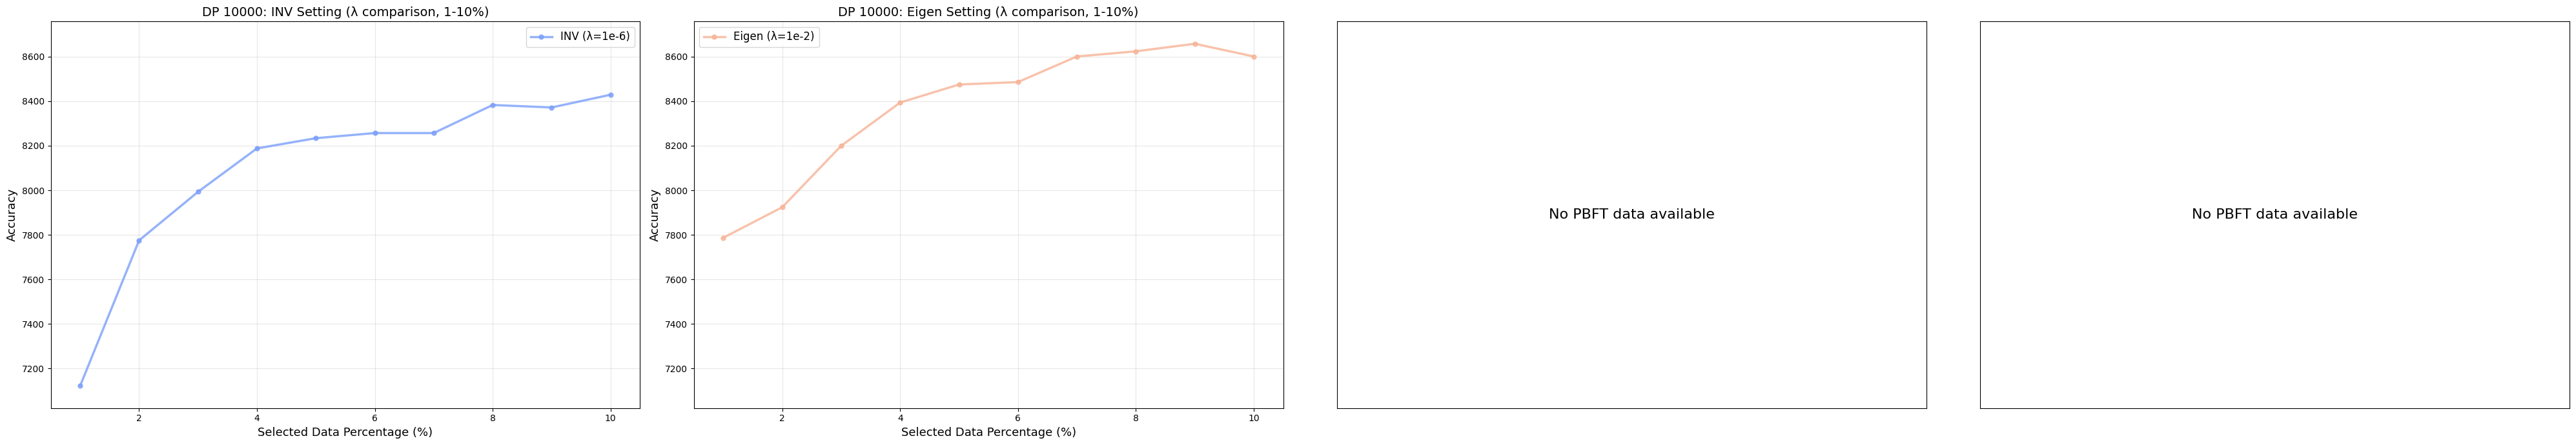

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 10000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [7122, 7775, 7993, 8188, 8234, 8257, 8257, 8383, 8372, 8429, 8440, 8544, 8658, 8658, 8635, 8704, 8612, 8647, 8647, 8727, 8716, 8739, 8773, 8830, 8842, 8865, 8853, 8876, 8842, 8842, 8830, 8853, 8853, 8842, 8911, 8853, 8842, 8888, 8933, 8888, 8922, 8876, 8911, 8876, 8876, 8876, 8865, 8899, 8865, 8865, 8876, 8842, 8842, 8830, 8865, 8853, 8876, 8876, 8842, 8876, 8853, 8888, 8911, 8922, 8933, 8911, 8911, 8888, 8899, 8888, 8888, 8911, 8911, 8922, 8933, 8899, 8945, 8956, 8899, 8922, 8888, 8911, 8911, 8911, 8945, 8945, 8933, 8922, 8933, 8888, 8876, 8876, 8888, 8876, 8807, 8830, 8693, 8761, 8716, 8589]  
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [7787, 7924, 8200, 8394, 8475, 8486, 8601, 8624, 8658, 8601, 8693, 8635, 8635, 8624, 8635, 8624, 8681, 8750, 8727, 8807, 8796, 8761, 8830, 8796, 8830, 8784, 8830, 8899, 8979, 8979, 9014, 8979, 9014, 9048, 9025, 9025, 9025, 9037, 9060, 9071, 9106, 9071, 9083, 9071, 9025, 9014, 9037, 9037, 9014, 9060, 9048, 9060, 9048, 9094, 9048, 9037, 9037, 9048, 9060, 9002, 9037, 9014, 8991, 8979, 9014, 8979, 9037, 9025, 9060, 9025, 8979, 9048, 9002, 9037, 8991, 8968, 9002, 9014, 9002, 8979, 9014, 8979, 8979, 8991, 9002, 8979, 8968, 8933, 8853, 8888, 8830, 8819, 8819, 8773, 8773, 8739, 8727, 8693, 8704, 8578]  
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6      = [6972, 7867, 8062, 8131, 8096, 8142, 8234, 8177, 8245, 8200, 8383, 8383, 8452, 8498, 8486, 8406, 8360, 8509, 8486, 8509, 8417, 8532, 8452, 8417, 8498, 8452, 8463, 8486, 8486, 8417, 8372, 8372, 8509, 8440, 8486, 8509, 8498, 8463, 8486, 8486, 8578, 8532, 8532, 8498, 8486, 8555, 8567, 8498, 8532, 8486, 8544, 8486, 8521, 8532, 8521, 8486, 8555, 8509, 8544, 8555, 8498, 8544, 8544, 8532, 8475, 8498, 8509, 8486, 8498, 8567, 8532, 8555, 8567, 8555, 8532, 8567, 8589, 8578, 8532, 8532, 8567, 8589, 8578, 8567, 8544, 8567, 8589, 8624, 8601, 8612, 8612, 8578, 8658, 8589, 8578, 8601, 8612, 8589, 8601, 8589]
r_inv_lam1e_5      = None
r_inv_lam1e_4      = None
r_inv_lam1e_3      = None
r_inv_lam1e_2      = None
r_inv_lam1e_1      = None
r_eigen_lam1e_6    = None
r_eigen_lam1e_5    = None
r_eigen_lam1e_4    = None
r_eigen_lam1e_3    = None
r_eigen_lam1e_2    = [6835, 7764, 7947, 7878, 7890, 7982, 8119, 8050, 8085, 8119, 8165, 8188, 8154, 8165, 8188, 8085, 8177, 8222, 8234, 8234, 8245, 8177, 8245, 8326, 8280, 8349, 8257, 8280, 8257, 8200, 8303, 8211, 8257, 8268, 8360, 8372, 8326, 8314, 8383, 8383, 8337, 8326, 8337, 8326, 8314, 8257, 8245, 8234, 8303, 8280, 8372, 8429, 8360, 8417, 8429, 8406, 8406, 8417, 8360, 8372, 8394, 8383, 8406, 8417, 8372, 8394, 8417, 8521, 8475, 8532, 8463, 8486, 8486, 8509, 8429, 8475, 8429, 8498, 8509, 8544, 8578, 8544, 8544, 8589, 8555, 8555, 8555, 8601, 8635, 8658, 8635, 8658, 8647, 8647, 8601, 8612, 8624, 8578, 8624, 8578]
r_eigen_lam1e_1    = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
colors = colors[::-1]  # Reverse colors: high lambda (1e-1) gets red, low lambda (1e-6) gets blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[1] if len(colors) > 1 else colors[-1]  # Lambda 1e-2 color (index 1)

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Define zoom range for subplots (1,1) and (1,2)
zoom_percent = 10
zoom_range = selected_dp_percent[:zoom_percent]

# ===== Subplot (1,1): INV Setting (λ comparison, 1-10%) =====
ax_left = axes[0]

# INV lambda configs (1e-1 to 1e-6)
inv_lambdas = [
    (inv_lam1e_1, '1e-1'),
    (inv_lam1e_2, '1e-2'),
    (inv_lam1e_3, '1e-3'),
    (inv_lam1e_4, '1e-4'),
    (inv_lam1e_5, '1e-5'),
    (inv_lam1e_6, '1e-6')
]

# Plot INV with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(inv_lambdas):
    if data is not None:
        ax_left.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'INV (λ={lam_label})', alpha=0.8)

ax_left.set_xlim(0.5, zoom_percent + 0.5)
ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen Setting (λ comparison, 1-10%) =====
ax_middle = axes[1]

# Eigen lambda configs (1e-1 to 1e-6)
eigen_lambdas = [
    (eigen_lam1e_1, '1e-1'),
    (eigen_lam1e_2, '1e-2'),
    (eigen_lam1e_3, '1e-3'),
    (eigen_lam1e_4, '1e-4'),
    (eigen_lam1e_5, '1e-5'),
    (eigen_lam1e_6, '1e-6')
]

# Plot Eigen with different lambda values (1-10% only)
for i, (data, lam_label) in enumerate(eigen_lambdas):
    if data is not None:
        ax_middle.plot(zoom_range, data[:zoom_percent], 
                 color=colors[i], linewidth=2.5, linestyle='-', 
                 marker='o', markersize=5,
                 label=f'Eigen (λ={lam_label})', alpha=0.8)

ax_middle.set_xlim(0.5, zoom_percent + 0.5)
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ comparison, 1-{zoom_percent}%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Synchronize y-axis for (1,1) and (1,2) =====
# Collect all values from both subplots
all_values = []
for data, _ in inv_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])
for data, _ in eigen_lambdas:
    if data is not None:
        all_values.extend(data[:zoom_percent])

# Set same y-axis limits for both subplots
if all_values:
    y_min = min(all_values) - 100
    y_max = max(all_values) + 100
    ax_left.set_ylim(y_min, y_max)
    ax_middle.set_ylim(y_min, y_max)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10% data (zoom in)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid, circle marker) and PBFT (dashed, square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlim(0.5, 10.5)
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()